## This program performs a statistical analysis of the data to determine which $hr_d$ and $\Omega_m$ perform best

In [1]:
#importing modules
import numpy as np
import matplotlib.pyplot as plt 
from fonction import DHrd, trapezeVect, DMrd,DHrdw0wa, DMrdw0wa
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [2]:
#DESI DR2 Data
mu = np.array([0.31655,98.9279])
CovCMB = np.array([[7.093e-05,-8.834e-03],[-8.834e-03,1.102]])
CovCMBI = np.linalg.inv(CovCMB)	
redshift = np.array([0.510,0.706,0.934,1.321,1.484,2.330])
DMrd_data = np.array([13.588,17.351,21.576,27.601,30.512,38.988])
DHrd_data = np.array([21.863,19.455,17.641,14.176,12.817,8.632])
IDMrd = np.array([0.167,0.177,0.152,0.318,0.760,0.531])
IDHrd = np.array([0.425,0.330,0.193,0.221,0.516,0.101])
rMH = np.array([-0.459,-0.404,-0.416,-0.434,-0.500,-0.431])

In [3]:
#Definition of BAO and CMB likelihood
n = len(IDMrd)
z = len(redshift)
size = 2*n
size2 = 2*z
C = np.zeros((size,size))
for i in range (n) :
	C[i*2,i*2] = IDMrd[i]**2
	C[i*2+1,i*2+1] = IDHrd[i]**2
	C[i*2,i*2+1] = rMH[i]*IDMrd[i]*IDHrd[i]
	C[i*2+1,i*2] = rMH[i]*IDMrd[i]*IDHrd[i]
Cinv=np.linalg.inv(C)
def log_likelihood (hrd,Om) :
	Ol = 1-Om
	md = np.zeros((size2,1))
	DHrd_model = DHrd(redshift,hrd,Om,Ol)
	DMrd_model = np.array([DMrd(zi, hrd, Om, Ol) for zi in redshift])
	for i in range (z):
		md[i*2,0]=DMrd_model[i]-DMrd_data[i]
		md[i*2+1,0] = DHrd_model[i]-DHrd_data[i]
	mdt = np.transpose(md)
	chi2BAO = float(mdt @ Cinv @ md )
	dx = np.array([Om, hrd]) - mu
	chi2CMB = float(dx @ CovCMBI @ dx)
	chi2 = chi2BAO+chi2CMB
	return -1/2*chi2BAO, -1/2*chi2CMB

In [4]:
#grid calculation 
hrd_grid = np.linspace(96,105.19,100)
Om_grid = np.linspace(0.2545,0.3405,100)
likelihood_gridBAO = np.zeros((100,100))
likelihood_gridCMB = np.zeros((100,100))
for i, hrd in enumerate (hrd_grid): 
	for j, Om in enumerate (Om_grid) :
		result = log_likelihood(hrd, Om,)
		likelihood_gridBAO[i,j] = result[0]
		likelihood_gridCMB[i,j] = result[1]

C:\Users\louar\AppData\Local\Temp\ipykernel_12312\26050108.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2BAO = float(mdt @ Cinv @ md )


In [5]:
#Bestfit BAO, CMB
log_likemaxBAO = np.max(likelihood_gridBAO)
i_maxBAO, j_maxBAO = np.unravel_index(np.argmax(likelihood_gridBAO), likelihood_gridBAO.shape)
hrd_bestfitBAO = hrd_grid[i_maxBAO]
Om_bestfitBAO  = Om_grid[j_maxBAO]

log_likemaxCMB = np.max(likelihood_gridCMB)
i_maxCMB, j_maxCMB = np.unravel_index(np.argmax(likelihood_gridCMB), likelihood_gridCMB.shape)
hrd_bestfitCMB = hrd_grid[i_maxCMB]
Om_bestfitCMB  = Om_grid[j_maxCMB]

In [6]:
#BAO analysis
profile_loglike_OmBAO = np.max(likelihood_gridBAO, axis=0)
profile_loglike_hrdBAO = np.max(likelihood_gridBAO, axis=1)
delta_loglike_OmBAO = log_likemaxBAO - profile_loglike_OmBAO
delta_loglike_hrdBAO = log_likemaxBAO - profile_loglike_hrdBAO
print(f'maxgridBAO = {log_likemaxBAO}, maxOmBAO = {np.max(profile_loglike_OmBAO)}, maxhrdBAO = {np.max(profile_loglike_hrdBAO)}') 

indices_OmBAO = np.where(delta_loglike_OmBAO <= 0.5)[0]
Om_min_errBAO = Om_grid[indices_OmBAO[0]]
Om_max_errBAO = Om_grid[indices_OmBAO[-1]]
indices_hrdBAO = np.where(delta_loglike_hrdBAO <= 0.5)[0]
hrd_min_errBAO = hrd_grid[indices_hrdBAO[0]]
hrd_max_errBAO = hrd_grid[indices_hrdBAO[-1]]

print(f"OmBAO  = {Om_bestfitBAO:.3f} +{Om_max_errBAO - Om_bestfitBAO:.3f} -{Om_bestfitBAO - Om_min_errBAO:.3f}")
print(f"hrdBAO = {hrd_bestfitBAO:.3f} +{hrd_max_errBAO - hrd_bestfitBAO:.3f} -{hrd_bestfitBAO - hrd_min_errBAO:.3f}")
print(f"hrd best fitBAO = {hrd_bestfitBAO:.3f}")
print(f"Om best fitBAO  = {Om_bestfitBAO:.3f}")
sig1BAO = log_likemaxBAO-1.15
sig2BAO = log_likemaxBAO-3.09

maxgridBAO = -5.0789227813023565, maxOmBAO = -5.0789227813023565, maxhrdBAO = -5.0789227813023565
OmBAO  = 0.295 +0.009 -0.010
hrdBAO = 101.848 +0.835 -0.743
hrd best fitBAO = 101.848
Om best fitBAO  = 0.295


In [7]:
#CMB analysis
profile_loglike_OmCMB = np.max(likelihood_gridCMB, axis=0)
profile_loglike_hrdCMB = np.max(likelihood_gridCMB, axis=1)
delta_loglike_OmCMB = log_likemaxCMB - profile_loglike_OmCMB
delta_loglike_hrdCMB = log_likemaxCMB - profile_loglike_hrdCMB
print(f'maxgridCMB = {log_likemaxCMB}, maxOmCMB = {np.max(profile_loglike_OmCMB)}, maxhrdXMB = {np.max(profile_loglike_hrdCMB)}') 

indices_OmCMB = np.where(delta_loglike_OmCMB <= 0.5)[0]
Om_min_errCMB = Om_grid[indices_OmCMB[0]]
Om_max_errCMB = Om_grid[indices_OmCMB[-1]]
indices_hrdCMB = np.where(delta_loglike_hrdCMB <= 0.5)[0]
hrd_min_errCMB = hrd_grid[indices_hrdCMB[0]]
hrd_max_errCMB = hrd_grid[indices_hrdCMB[-1]]

print(f"OmCMB  = {Om_bestfitCMB:.3f} +{Om_max_errCMB - Om_bestfitCMB:.3f} -{Om_bestfitCMB - Om_min_errCMB:.3f}")
print(f"hrdCMB = {hrd_bestfitCMB:.3f} +{hrd_max_errCMB - hrd_bestfitCMB:.3f} -{hrd_bestfitCMB - hrd_min_errCMB:.3f}")
print(f"hrd best fitCMB = {hrd_bestfitCMB:.3f}")
print(f"Om best fit CMB = {Om_bestfitCMB:.3f}")
sig1CMB = log_likemaxCMB-1.15
sig2CMB = log_likemaxCMB-3.09


maxgridCMB = -0.005241285615062277, maxOmCMB = -0.005241285615062277, maxhrdXMB = -0.005241285615062277
OmCMB  = 0.316 +0.007 -0.006
hrdCMB = 98.971 +0.743 -0.835
hrd best fitCMB = 98.971
Om best fit CMB = 0.316


Marginalized posterior constraints on $H_0r_d$ and $\Omega_m$ from DR2 BAO and the CMB, computed under the assumption of a $\Lambda$CDM cosmology.

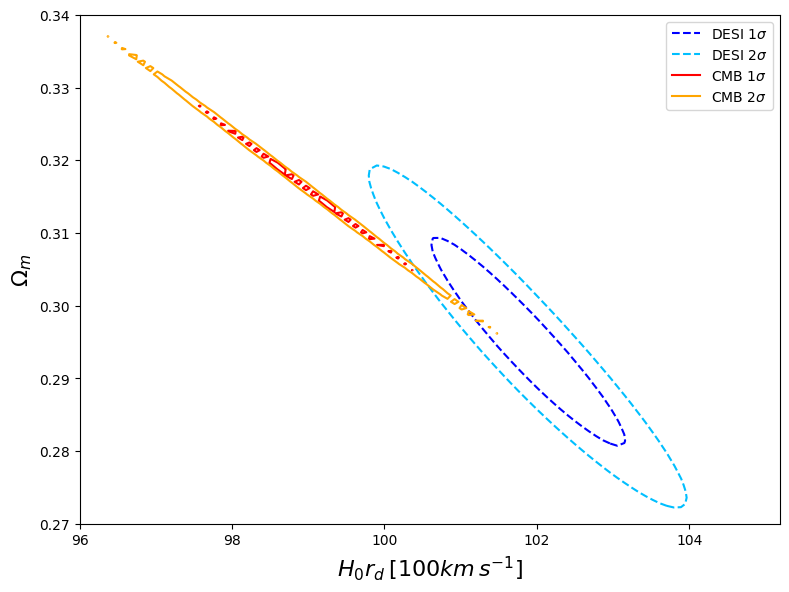

In [8]:
fig, ax = plt.subplots(figsize=(8,6))
c1 = ax.contour(hrd_grid, Om_grid, likelihood_gridBAO.T, levels=[sig1BAO],linestyles = '--', colors=['blue'])
c2 = ax.contour(hrd_grid, Om_grid, likelihood_gridBAO.T, levels=[sig2BAO], linestyles = '--',colors=['deepskyblue'])
c3 = ax.contour(hrd_grid, Om_grid, likelihood_gridCMB.T, levels=[sig1CMB],linestyles = '-', colors=['red'])
c4 = ax.contour(hrd_grid, Om_grid, likelihood_gridCMB.T, levels=[sig2CMB], linestyles = '-',colors=['orange'])
#p1, = ax.plot(hrd_bestfitBAO, Om_bestfitBAO, '*', color='blue', markersize=10, label='best fit BAO')
#p2, = ax.plot(hrd_bestfitCMB, Om_bestfitCMB, '*', color='red', markersize=10, label='best fit CMB')
patch1 = mlines.Line2D([], [], color='blue', linestyle='--' ,    label=r'DESI $1\sigma$')
patch2 = mlines.Line2D([], [], color='deepskyblue',linestyle ='--',label=r'DESI $2\sigma$')
patch3 = mlines.Line2D([], [], color='red',linestyle = '-',   label=r'CMB $1\sigma$')
patch4 = mlines.Line2D([], [], color='orange',linestyle = '-',  label=r'CMB $2\sigma$')
ax.legend(handles=[patch1, patch2, patch3, patch4], fontsize=10)
ax.set_xlabel(r'$H_0 r_d \: [100 km\, s^{-1}]$', fontsize=16)
ax.set_ylabel(r'$\Omega_m$', fontsize=16)
plt.tight_layout()
plt.ylim(0.27,0.34)
plt.savefig('OmHrd100DESICMBRapport.pdf', dpi=300)
plt.show()
